In [2]:
import pandas as pd
from pathlib import Path

file_path = Path.home() / "Downloads" / "dec 2024 data.csv"
df = pd.read_csv(file_path)

print(df.head())
print(df.columns)

       Date Carrier  Airline Name  Flight_Num Origin Dest  Dep_Time  \
0  12/31/24      9E  Endeavor Air        4780    ATL  TUL       820   
1  12/31/24      9E  Endeavor Air        4780    TUL  ATL      1018   
2  12/31/24      9E  Endeavor Air        4781    ATL  MDT      1110   
3  12/31/24      9E  Endeavor Air        4781    MDT  ATL      1350   
4  12/31/24      9E  Endeavor Air        4783    MDT  ATL       600   

   Actual_Dep  Delay  Cancelled  
0       819.0   -1.0          0  
1      1021.0    3.0          0  
2      1106.0   -4.0          0  
3      1342.0   -8.0          0  
4       607.0    7.0          0  
Index(['Date', 'Carrier', 'Airline Name', 'Flight_Num', 'Origin', 'Dest',
       'Dep_Time', 'Actual_Dep', 'Delay', 'Cancelled'],
      dtype='object')


In [3]:
df = df[df['Cancelled'] == 0]

df['Cancelled'].value_counts()

0    627365
Name: Cancelled, dtype: int64

In [4]:
df['Delayed'] = (df['Delay'] > 15).astype(int)

df[['Delay', 'Delayed']].head()

,Delay,Delayed
0,-1.0,0
1,3.0,0
2,-4.0,0
3,-8.0,0
4,7.0,0


In [5]:
y = df['Delayed']

X = df.drop(['Delayed', 'Delay'], axis=1)

In [6]:
X = X.drop(['Actual_Dep', 'Flight_Num', 'Airline Name'], axis=1)

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

X['Month'] = df['Date'].dt.month
X['DayOfWeek'] = df['Date'].dt.dayofweek

X = X.drop('Date', axis=1)

In [8]:
X = pd.get_dummies(X, drop_first=True)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model_15 = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

sample_weights = y_train.apply(lambda x: 5 if x == 1 else 1)

gb_model_15.fit(X_train, y_train, sample_weight=sample_weights)

GradientBoostingClassifier(random_state=42)

In [11]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_15 = gb_model_15.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_15))
print(classification_report(y_test, y_pred_15))

Accuracy: 0.46344631912841805
              precision    recall  f1-score   support

           0       0.89      0.37      0.52     99702
           1       0.25      0.82      0.38     25771

    accuracy                           0.46    125473
   macro avg       0.57      0.59      0.45    125473
weighted avg       0.76      0.46      0.50    125473



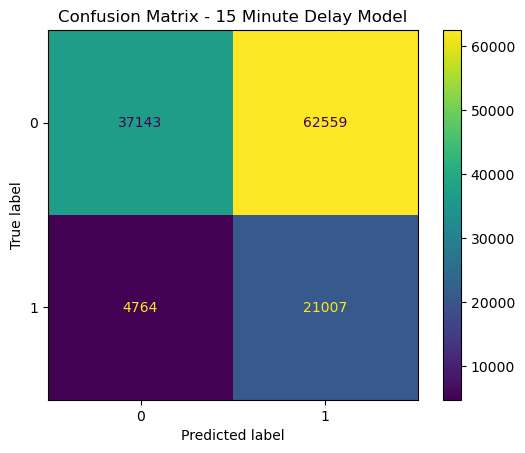

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_15 = confusion_matrix(y_test, y_pred_15)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_15)
disp.plot()

plt.title("Confusion Matrix - 15 Minute Delay Model")
plt.show()

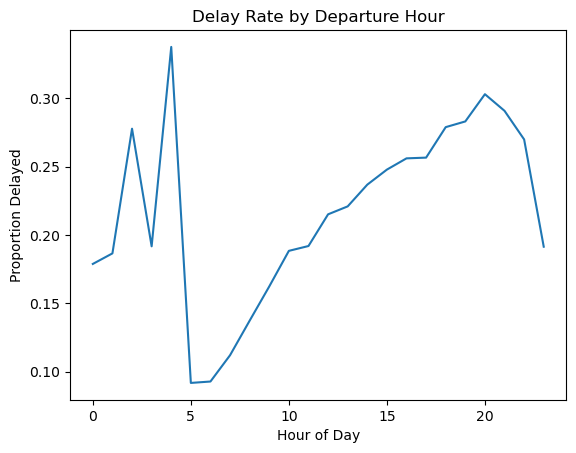

In [13]:
df['Hour'] = df['Dep_Time'] // 100

delay_by_hour = df.groupby('Hour')['Delayed'].mean()

import matplotlib.pyplot as plt

plt.figure()
delay_by_hour.plot(kind='line')

plt.title("Delay Rate by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Proportion Delayed")

plt.show()

In [14]:
delay_by_carrier = df.groupby('Carrier')['Delayed'].mean().sort_values(ascending=False)

delay_by_carrier.head(10)

Carrier
B6    0.295478
G4    0.265965
OH    0.254317
G7    0.251526
NK    0.240250
F9    0.231333
AA    0.227520
WN    0.226677
AS    0.207004
PT    0.205181
Name: Delayed, dtype: float64

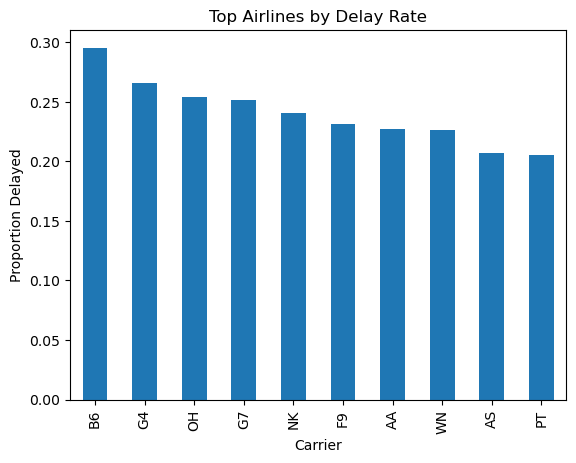

In [15]:
delay_by_carrier.head(10).plot(kind='bar')

plt.title("Top Airlines by Delay Rate")
plt.ylabel("Proportion Delayed")
plt.show()